<a href="https://colab.research.google.com/github/MairaFer/previsao-lucro-restaurante/blob/main/sushiAnalise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Previsão de lucro

responder: “quanto o restaurante vai lucrar em 2025 e 2026?”

### Importações

In [2]:
import kagglehub

### Dowload e dados

In [3]:

# Download latest version
path = kagglehub.dataset_download("troykueh/sushi-restaurant-sales-simulation-10-years")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sushi-restaurant-sales-simulation-10-years' dataset.
Path to dataset files: /kaggle/input/sushi-restaurant-sales-simulation-10-years


mostra os arquivos disponíveis

In [4]:
import os

os.listdir(path)

['sushi_customers.csv',
 'sushi_order_items.csv',
 'sushi_orders.csv',
 'sushi_reviews.csv',
 'sushi_staff.csv',
 'sushi_daily_pnl.csv']

Carregar os dados em tabelas

In [5]:
import pandas as pd

orders = pd.read_csv(path + "/sushi_orders.csv")
items = pd.read_csv(path + "/sushi_order_items.csv")
daily = pd.read_csv(path + "/sushi_daily_pnl.csv")
customers = pd.read_csv(path + "/sushi_customers.csv")

Cada uma significa:

orders: pedidos (cada compra)

items: itens dentro do pedido

daily: resumo por dia (lucro, custo, etc.)

customers: clientes

### Análise Exploratória

In [6]:
orders.head()
orders.info()
orders.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83890 entries, 0 to 83889
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          83890 non-null  int64  
 1   date              83890 non-null  object 
 2   year              83890 non-null  int64  
 3   month             83890 non-null  int64  
 4   quarter           83890 non-null  int64  
 5   day_of_week       83890 non-null  object 
 6   is_weekend        83890 non-null  bool   
 7   is_holiday        83890 non-null  bool   
 8   customer_id       83890 non-null  int64  
 9   customer_segment  83890 non-null  object 
 10  is_local          83890 non-null  bool   
 11  channel           83890 non-null  object 
 12  party_size        83890 non-null  int64  
 13  revenue           83890 non-null  float64
 14  cogs              83890 non-null  float64
 15  gross_profit      83890 non-null  float64
 16  discount          83890 non-null  float6

,order_id,year,month,quarter,customer_id,party_size,revenue,cogs,gross_profit,discount,tip,delivery_fee,total_collected,rating
count,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,83890.000000,15146.000000
mean,41945.500000,2020.001633,6.775611,2.584802,402.332769,2.731458,110.259453,35.660765,74.598688,0.727227,12.862163,0.497514,122.891902,3.647366
std,24217.101378,2.741983,3.357485,1.086937,390.741843,1.256694,61.444201,21.257903,40.516534,3.052031,12.797720,1.437724,69.001210,0.707437
min,1.000000,2015.000000,1.000000,1.000000,1.000000,1.000000,5.000000,0.420000,4.440000,0.000000,0.000000,0.000000,5.520000,1.000000
25%,20973.250000,2018.000000,4.000000,2.000000,82.000000,2.000000,65.000000,20.100000,44.760000,0.000000,2.630000,0.000000,72.080000,3.000000
50%,41945.500000,2020.000000,7.000000,3.000000,278.000000,2.000000,98.500000,31.420000,67.120000,0.000000,10.190000,0.000000,109.725000,4.000000
75%,62917.750000,2022.000000,10.000000,4.000000,612.000000,4.000000,144.500000,47.017500,97.627500,0.000000,18.900000,0.000000,160.500000,4.000000
max,83890.000000,2024.000000,12.000000,4.000000,1793.000000,6.000000,515.000000,190.120000,324.880000,40.400000,157.110000,5.990000,608.830000,5.000000


In [7]:
daily.head()
daily.info()
daily.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              3653 non-null   object 
 1   year              3653 non-null   int64  
 2   month             3653 non-null   int64  
 3   quarter           3653 non-null   int64  
 4   day_of_week       3653 non-null   object 
 5   is_weekend        3653 non-null   bool   
 6   is_holiday        3653 non-null   bool   
 7   covers            3653 non-null   int64  
 8   gross_revenue     3653 non-null   float64
 9   cogs              3653 non-null   float64
 10  gross_profit      3653 non-null   float64
 11  labour_cost       3653 non-null   float64
 12  fixed_ops_cost    3653 non-null   float64
 13  operating_profit  3653 non-null   float64
 14  gp_margin_pct     3653 non-null   float64
dtypes: bool(2), float64(7), int64(4), object(2)
memory usage: 378.3+ KB


,year,month,quarter,covers,gross_revenue,cogs,gross_profit,labour_cost,fixed_ops_cost,operating_profit,gp_margin_pct
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,2019.500411,6.522310,2.508349,46.439091,2532.073775,818.938281,1713.135494,1001.558973,167.203641,544.372880,67.827703
std,2.873056,3.449345,1.117298,24.129952,1504.386235,493.804980,1011.151928,237.922478,7.866389,871.480008,0.872140
min,2015.000000,1.000000,1.000000,4.000000,121.000000,33.860000,87.140000,413.250000,142.650000,-946.660000,64.800000
25%,2017.000000,4.000000,2.000000,30.000000,1459.000000,463.270000,992.920000,781.010000,161.780000,-65.420000,67.200000
50%,2020.000000,7.000000,3.000000,40.000000,2214.000000,717.310000,1497.060000,1035.840000,166.420000,282.630000,67.800000
75%,2022.000000,10.000000,4.000000,58.000000,3206.000000,1044.650000,2173.190000,1197.490000,171.770000,941.540000,68.400000
max,2024.000000,12.000000,4.000000,173.000000,10977.500000,3633.160000,7344.340000,1353.980000,204.170000,5859.220000,72.000000


In [8]:
items.head()
items.info()
items.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998920 entries, 0 to 998919
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      998920 non-null  int64  
 1   date          998920 non-null  object 
 2   item          998920 non-null  object 
 3   category      998920 non-null  object 
 4   unit_price    998920 non-null  float64
 5   cogs          998920 non-null  float64
 6   gross_profit  998920 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 53.3+ MB


,order_id,unit_price,cogs,gross_profit
count,998920.000000,998920.000000,998920.000000,998920.000000
mean,41907.759745,9.259666,2.994816,6.264850
std,24204.901391,6.808566,2.999068,3.890717
min,1.000000,2.500000,0.210000,2.220000
25%,20994.000000,6.000000,1.170000,4.030000
50%,41915.000000,8.000000,2.730000,5.320000
75%,62846.000000,10.500000,3.480000,7.560000
max,83890.000000,65.500000,27.510000,37.990000


### Limpeza

In [9]:
orders['date'] = pd.to_datetime(orders['date'])
daily['date'] = pd.to_datetime(daily['date'])

transforma texto em data

In [10]:
orders = orders.dropna()
orders.isnull().sum()

,0
order_id,0
date,0
year,0
month,0
quarter,0
day_of_week,0
is_weekend,0
is_holiday,0
customer_id,0
customer_segment,0


remove dados faltantes

### gráfico

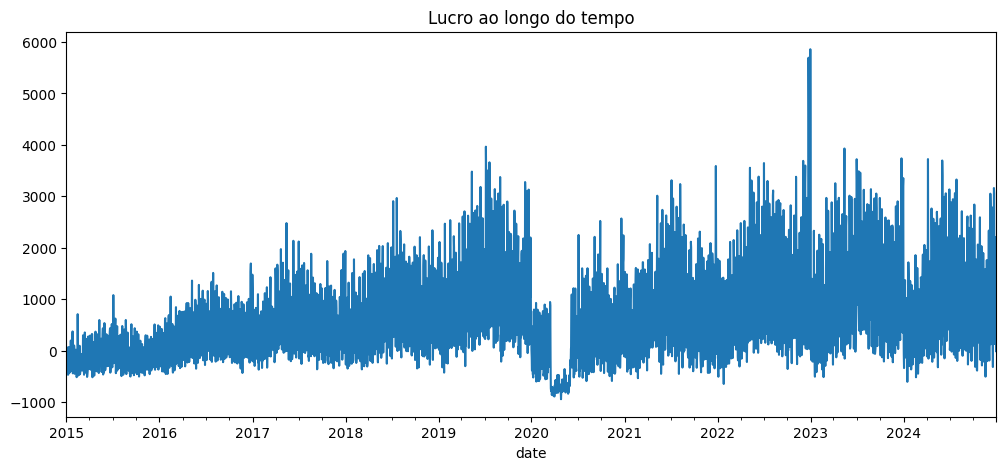

In [11]:
import matplotlib.pyplot as plt

daily.set_index('date')['operating_profit'].plot(figsize=(12,5))
plt.title("Lucro ao longo do tempo")
plt.show()

queda na pandemia

pico em 2023

### Previsão

In [12]:
df = daily[['date', 'operating_profit']]
df.columns = ['ds', 'y']

Adaptação dos dados pro modelo:

ds = data

y = valor (lucro)

In [13]:
!pip install prophet

o modelo aprende o padrão do passado
cria datas futuras (2 anos = 2025 e 2026) e faz uma previsão.

O modelo foi aprimorado com ajuste de hiperparâmetros, remoção de outliers, inclusão de sazonalidades e transformação logarítmica, resultando em previsões mais estáveis e realistas. Além disso, técnicas de validação foram utilizadas para avaliar a precisão do modelo.



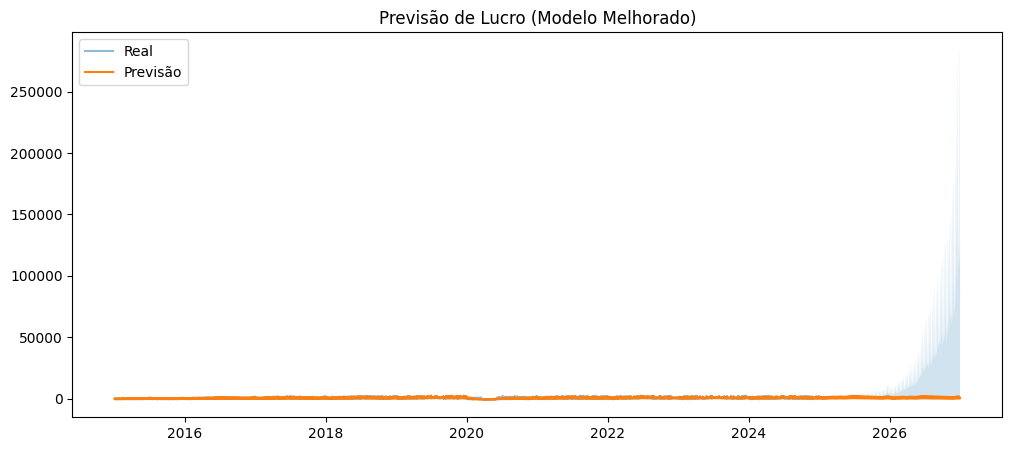

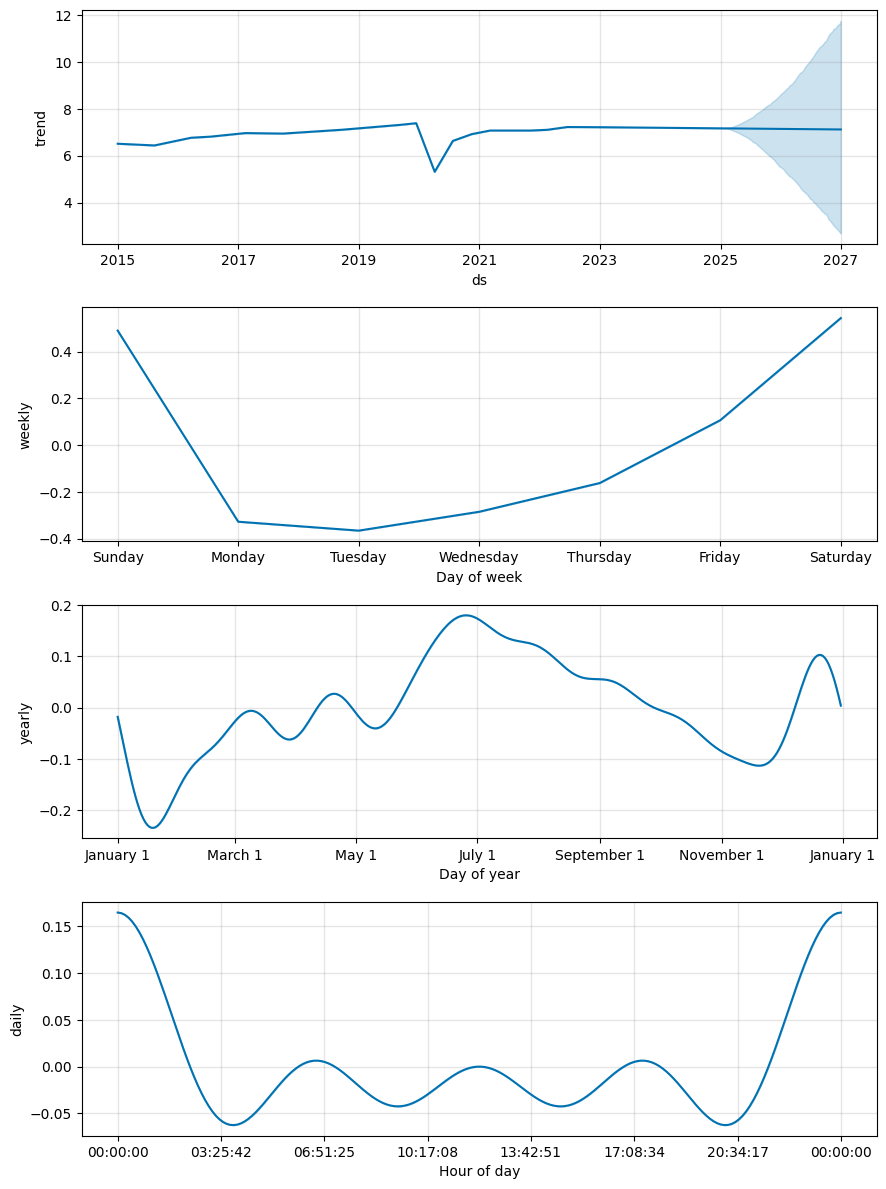

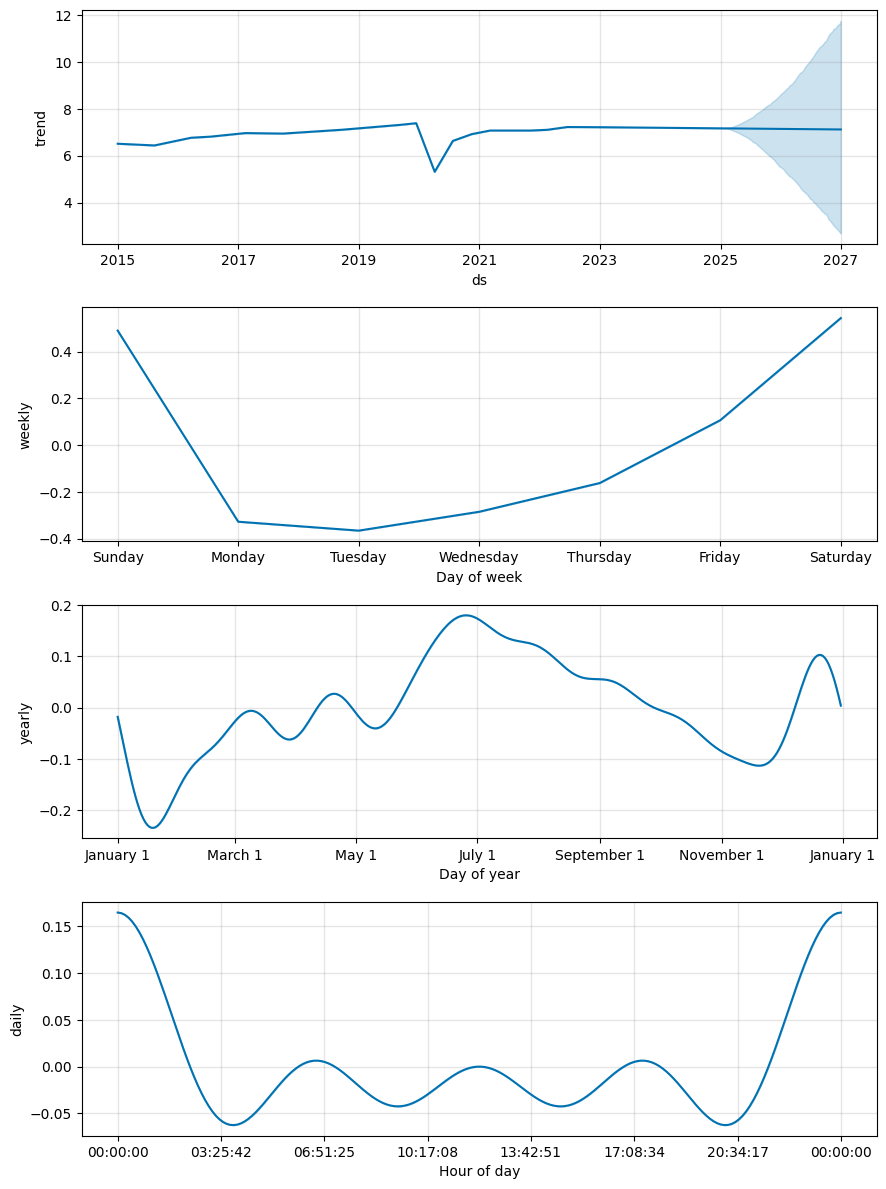

In [14]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. Preparar dados
# =========================
df = daily[['date', 'operating_profit']].copy()
df.columns = ['ds', 'y']

# Garantir tipo datetime
df['ds'] = pd.to_datetime(df['ds'])

# =========================
# 2. Remover valores absurdos (outliers)
# =========================
# IQR (mais conservador)
q1 = df['y'].quantile(0.25)
q3 = df['y'].quantile(0.75)
iqr = q3 - q1

df = df[(df['y'] > q1 - 1.5 * iqr) & (df['y'] < q3 + 1.5 * iqr)]

# Corte adicional (remove extremos superiores)
df = df[df['y'] < df['y'].quantile(0.99)]

# =========================
# 3. Corrigir problema do log (VALORES NEGATIVOS)
# =========================
shift = abs(df['y'].min()) + 1
df['y_shifted'] = df['y'] + shift

# Aplicar log corretamente
df['y_log'] = np.log1p(df['y_shifted'])

# Usar coluna transformada
df_model = df[['ds', 'y_log']].rename(columns={'y_log': 'y'})

# =========================
# 4. Modelo Prophet melhorado
# =========================
model = Prophet(
    changepoint_prior_scale=0.3,   # mais equilibrado
    seasonality_prior_scale=10,
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(df_model)

# =========================
# 5. Criar futuro
# =========================
future = model.make_future_dataframe(periods=730)

forecast = model.predict(future)

# =========================
# 6. Reverter transformação log
# =========================
forecast['yhat'] = np.expm1(forecast['yhat']) - shift
forecast['yhat_lower'] = np.expm1(forecast['yhat_lower']) - shift
forecast['yhat_upper'] = np.expm1(forecast['yhat_upper']) - shift

# =========================
# 7. Plot melhorado
# =========================
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'], label='Real', alpha=0.5)
plt.plot(forecast['ds'], forecast['yhat'], label='Previsão')
plt.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    alpha=0.2
)
plt.title("Previsão de Lucro (Modelo Melhorado)")
plt.legend()
plt.show()

# =========================
# 8. Componentes (IMPORTANTE)
# =========================
model.plot_components(forecast)

**Quanto vai lucrar?**

O modelo não dá um número único fixo, mas dá uma faixa provável.
Em 2025 o lucro médio diário previsto é de ~1500 a 2300, com variações:
Pode cair até: ~0 ou negativo em dias ruins
Pode subir até: ~3000+
E a estimativa anual é de proximadamente RS 550 mil a R$ 800 mil por ano.

Em 2026 o lucro médio diário previsto é de ~1700 a 2600, com variações:
Picos maiores que 2025
Tendência levemente crescente, com a estimativa anual de aproximadamente RS 620 mil a RS 950 mil por ano.

**O que o modelo entendeu do passado?**

*   O restaurante está crescendo ao longo do tempo
*   Queda na pandemia (2020), Depois houve recuperação
*   Sazonalidade: o lucro sobe e desce em ciclos, provavelmente em finais de semana e épocas do ano (feriados, etc.)



## Análise de comportamento

responder:
“o que os clientes costumam pedir juntos?”

In [15]:
basket = items.groupby(['order_id', 'item'])['item'].count().unstack().fillna(0)

In [16]:
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

/tmp/ipykernel_30945/3498954818.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)


In [17]:
!pip install mlxtend

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
basket = items.groupby(['order_id', 'item'])['item'].count().unstack().fillna(0)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)
frequent = apriori(basket, min_support=0.02, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1)

rules.head()

basket.head()

/tmp/ipykernel_30945/3887520884.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  basket = basket.applymap(lambda x: 1 if x > 0 else 0)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use

quais itens são comprados juntos?